![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# 2x4 Multimode Interference Coupler (Optical Hybrid)

### 0.1. General libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
import importlib
import upvfab_design_tools

importlib.reload(upvfab_design_tools)
from upvfab_design_tools import MMI_EME, DC_EME


In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Ancho de las guías de entrada/salida como el ancho del tapper

El tapper tiene un ancho de 1.5 um, por lo que es necesario agregarle a las guias 0.5 um, considerando que ya miden 1 um. 

En este caso vamos a tener en cuenta una longitud de MMI de 3*L_pi/4 = 66.14 um con L_pi = 88.19 um. Y no la especificada de 61 um. 

Adicionalmente las entradas se encuentran a -3/8 y 1/8, esto para que esten alineadas con la salida, pues las salidas estarán a -3/8, -1/8, 1/8 y 3/8, esto siguiendo las especificaciónes del artículo titulado: "Miniaturization of 2 × 4 90-Degree Hybrid Optical Couplers"

In [ ]:

# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 7.5 # Student. Body width

# m = MMI_EME(VERBOSE=True)  ## --> Para ver el indice efectivo de cada uno de los modos que se propagan 
m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width_dw = 0.5 # Ancho adicional de la guia para que sea del tamaño del taper
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  88.19169148209313  µm


/home/au/pic-upv-TFM-Paula-Ortiz/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


----------------- ENTRADA INFERIOR -------------------


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1323 [00:00<?, ?it/s]

------- Pameters -------
MMI length 66.1438
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 1.9569
Total OUT power: 0.9434
Excess loss [dB] =  3.1687
------------------------
Power over OUTs:  ['0.2318', '0.2200', '0.2472', '0.2444']
Ratio over OUTs ['0.2457', '0.2332', '0.2621', '0.2591']
Phase over OUTs ['156.8918', '-69.9198', '111.5021', '154.5576']
----------------- ENTRADA SUPERIOR -------------------


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1323 [00:00<?, ?it/s]

------- Pameters -------
MMI length 66.1438
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 1.9569
Total OUT power: 0.9528
Excess loss [dB] =  3.1258
------------------------
Power over OUTs:  ['0.2472', '0.2562', '0.2297', '0.2196']
Ratio over OUTs ['0.2595', '0.2689', '0.2411', '0.2305']
Phase over OUTs ['111.5021', '154.4269', '158.5968', '-69.8907']


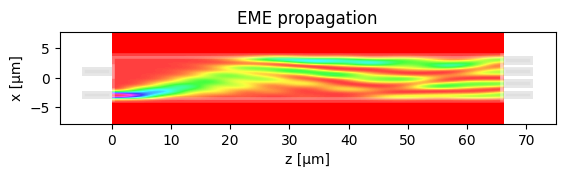

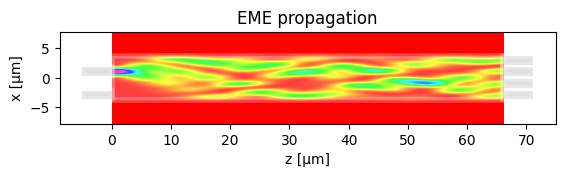

In [23]:
m.n_IN =  2 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.1

print("----------------- ENTRADA INFERIOR -------------------")
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-3/8, 1/8]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8,3/8]) + np.array([-dy,-dy,dy,dy]) # STUDENT

m.L_MMI = 3*L_pi/4
# MMI length (check class slides for type of MMI)
m.dL_MMI = 0 # STUDENT

# Run propagation
phase1=m.propagation()

print("----------------- ENTRADA SUPERIOR -------------------")
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([1/8, -3/8]) + np.array([dy,-dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8,3/8]) + np.array([-dy,-dy,dy,dy]) # STUDENT

# MMI length (check class slides for type of MMI)
# Run propagation
phase2=m.propagation()


In [24]:
delta_phase_total=phase1-phase2
print(f'Fase total a la salida del MMI: {delta_phase_total}')

phase_o1_o2=delta_phase_total[1]-delta_phase_total[0]
phase_o3_o4=delta_phase_total[3]-delta_phase_total[2]

print(f'Desfase de las dos primeras salidad del MMI: {np.round(phase_o1_o2,2)}')
print(f'Desfase de las dos ultimas salidad del MMI: {np.round(phase_o3_o4,2)}')

Fase total a la salida del MMI: [  45.38967442 -224.34668834  -47.09472518  224.44830295]
Desfase de las dos primeras salidad del MMI: -269.74
Desfase de las dos ultimas salidad del MMI: 271.54


## Para una longitud del MMI de 61 um 

----------------- ENTRADA INFERIOR -------------------


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1220 [00:00<?, ?it/s]

------- Pameters -------
MMI length 61.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 1.9569
Total OUT power: 0.8098
Excess loss [dB] =  3.8322
------------------------
Power over OUTs:  ['0.1550', '0.2767', '0.1227', '0.2554']
Ratio over OUTs ['0.1914', '0.3417', '0.1515', '0.3154']
Phase over OUTs ['-53.5287', '88.1244', '-74.3776', '-29.6656']
----------------- ENTRADA SUPERIOR -------------------


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/1220 [00:00<?, ?it/s]

------- Pameters -------
MMI length 61.0000
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.5000
------------------------
Total power IN coupled 1.9569
Total OUT power: 0.7272
Excess loss [dB] =  4.2992
------------------------
Power over OUTs:  ['0.1227', '0.2374', '0.0907', '0.2764']
Ratio over OUTs ['0.1687', '0.3265', '0.1248', '0.3801']
Phase over OUTs ['-74.3776', '-10.5423', '-26.4875', '88.0980']


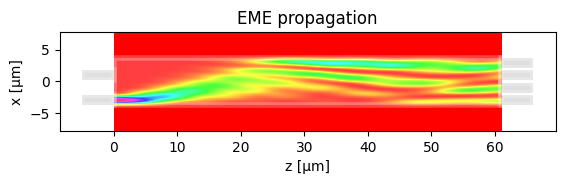

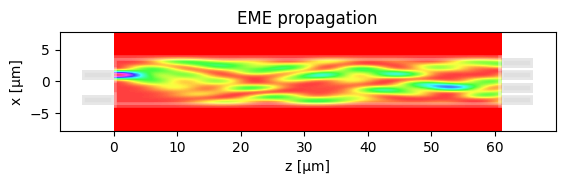

In [25]:
m.n_IN =  2 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.1

print("----------------- ENTRADA INFERIOR -------------------")
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-3/8, 1/8]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8,3/8]) + np.array([-dy,-dy,dy,dy]) # STUDENT

m.L_MMI = 61
# MMI length (check class slides for type of MMI)
m.dL_MMI = 0 # STUDENT

# Run propagation
phase1=m.propagation()

print("----------------- ENTRADA SUPERIOR -------------------")
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([1/8, -3/8]) + np.array([dy,-dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8,-1/8, 1/8,3/8]) + np.array([-dy,-dy,dy,dy]) # STUDENT

# MMI length (check class slides for type of MMI)
# Run propagation
phase2=m.propagation()


In [26]:
delta_phase_total=phase1-phase2
print(f'Fase total a la salida del MMI: {delta_phase_total}')

phase_o1_o2=delta_phase_total[1]-delta_phase_total[0]
phase_o3_o4=delta_phase_total[3]-delta_phase_total[2]

print(f'Desfase de las dos primeras salidad del MMI: {np.round(phase_o1_o2,2)}')
print(f'Desfase de las dos ultimas salidad del MMI: {np.round(phase_o3_o4,2)}')

Fase total a la salida del MMI: [  20.8488909    98.66669029  -47.89010955 -117.7636791 ]
Desfase de las dos primeras salidad del MMI: 77.82
Desfase de las dos ultimas salidad del MMI: -69.87


Como se observa en los resultados, con la longitud de 3/4 L_pi obtenemos una diferencia entre las salidas de -90 y 90 grados, mientras que para la longitud de 61 um, obtenemos una diferencia de 70 y -69 grados. 

Adicionalmente en ambos casos, si se halla la diferencia de fase de las salidas (luego de excitar las entradas por separado), no hay una diferencia de fase de 90 grados. 